# Figures 2 and 3: Human WM is associated with bursting in LMFG and RMTG

In [ ]:
# Adjust the path to the root data folder containing dataset_description.json, sourcedata/, etc.
DATA_PATH = "/Volumes/External/dataset/"
SUBJECTS = [f"sub-P{k}" for k in range(1, 8)]

In [8]:
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy import signal
from sklearn.linear_model import LinearRegression

# Adjust the path to the location of burst_toolbox
import sys
sys.path.append("/Users/vladimiromelyusik/burst_toolbox/src")

from burst_toolbox.dsp import compute_power
from burst_toolbox.stats import cluster_test_period
from burst_toolbox.bursts import detect_bursts, extract_burst_bounds

## Data processing

In [9]:
# Read the data
data = utils.read_openneuro(path = DATA_PATH, subjects = SUBJECTS)
data["sc"] = data["subject"] + "_" + data["channel"].astype(str)

data.head()

Extracting EDF parameters from /Volumes/External/dataset/sub-P1/ieeg/sub-P1_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P2/ieeg/sub-P2_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P3/ieeg/sub-P3_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P4/ieeg/sub-P4_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P5/ieeg/sub-P5_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /Volumes/External/dataset/sub-P6/ieeg/sub-P6_task-OWM_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters fr

,LFP_0,LFP_1,LFP_2,LFP_3,LFP_4,LFP_5,LFP_6,LFP_7,LFP_8,LFP_9,...,LFP_6495,LFP_6496,LFP_6497,subject,region,channel,modulated,trial_idx,n_correct,sc
0,32.028687,34.012360,35.965515,38.284886,42.282750,46.219577,48.905165,48.416876,47.501335,48.447395,...,28.000305,22.201877,19.211109,sub-P1,LMTG,23,1,1,0,sub-P1_23
1,-3.463798,-2.029450,-3.189136,-2.944991,-1.266499,-1.510643,-2.975509,-5.050736,-7.461662,-8.285649,...,15.274281,16.739147,17.746242,sub-P1,LMTG,23,1,3,0,sub-P1_23
2,-107.316701,-102.952621,-97.398337,-92.912184,-89.311055,-83.176928,-77.317464,-74.113069,-72.892348,-71.580072,...,-29.953460,-26.565957,-22.079805,sub-P1,LMTG,23,1,5,2,sub-P1_23
3,18.722820,19.394217,21.347372,24.551766,24.887465,23.544671,21.774624,19.607843,16.433967,13.076982,...,-25.528344,-26.199741,-27.908751,sub-P1,LMTG,23,1,8,3,sub-P1_23
4,-20.767529,-22.873274,-25.223163,-26.169223,-23.300526,-18.326085,-16.159304,-14.450294,-9.201190,-1.144427,...,-50.827802,-52.079042,-53.177691,sub-P1,LMTG,23,1,10,3,sub-P1_23


In [10]:
# Compute power and detect high gamma and beta bursts
processed_data = []

for region in ["LMFG", "RMTG"]:
    for freq_band in ["beta", "high_gamma"]:
        for subject_channel in data[data["region"] == region]["sc"].unique():
            subject, channel = subject_channel.split("_")
            channel = int(channel)
            
            # Compute power
            channel_data = data[(data["subject"] == subject) & (data["channel"] == channel)]
            power = compute_power(LFP = channel_data[utils.LFP_COLS].to_numpy(), freq_band = utils.FREQ_BANDS[freq_band])

            # Detect bursts
            bursts = detect_bursts(
                power = power,
                reference_period = np.array([1, 1000]),
                min_dur_ms = 3 * 1000 / np.mean(utils.FREQ_BANDS[freq_band])
            )

            composite = pd.DataFrame(np.hstack((power, bursts)), columns = utils.POWER_COLS + utils.BURST_COLS)
            composite["subject"] = subject
            composite["region"] = region
            composite["channel"] = channel
            composite["freq_band"] = freq_band
            composite["trial_idx"] = channel_data["trial_idx"].to_numpy()
            composite["modulated"] = channel_data["modulated"].to_numpy()
            composite["n_correct"] = channel_data["n_correct"].to_numpy()

            processed_data.append(composite)

processed_data = pd.concat(processed_data, axis = 0, ignore_index = True)
processed_data.head()

,power_0,power_1,power_2,power_3,power_4,power_5,power_6,power_7,power_8,power_9,...,bursts_6495,bursts_6496,bursts_6497,subject,region,channel,freq_band,trial_idx,modulated,n_correct
0,6.544030,6.646046,7.782911,8.412919,9.411584,10.192759,11.193510,12.118448,13.185223,14.266943,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,1,0,0
1,22.869988,21.754875,25.859255,27.594122,31.066299,33.319479,36.367352,38.748520,41.384938,43.700259,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,5,0,2
2,18.133333,13.194748,14.400935,14.721481,15.737993,16.884758,17.844060,19.368527,20.313834,22.074690,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,8,0,3
3,9.327621,9.027730,10.030496,10.360521,11.160145,11.586686,12.289968,12.757604,13.408420,13.907587,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,10,0,3
4,12.486770,11.636928,13.984695,15.061250,17.071779,18.609779,20.457306,22.228373,23.953539,25.845476,...,0.0,0.0,0.0,sub-P1,LMFG,6,beta,12,0,3


## Beta and high gamma power in LMFG (Fig. 2a) and RMTG (Fig. 3a)

**Note:** takes ~1 min. to run due to cluster testing.

/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)


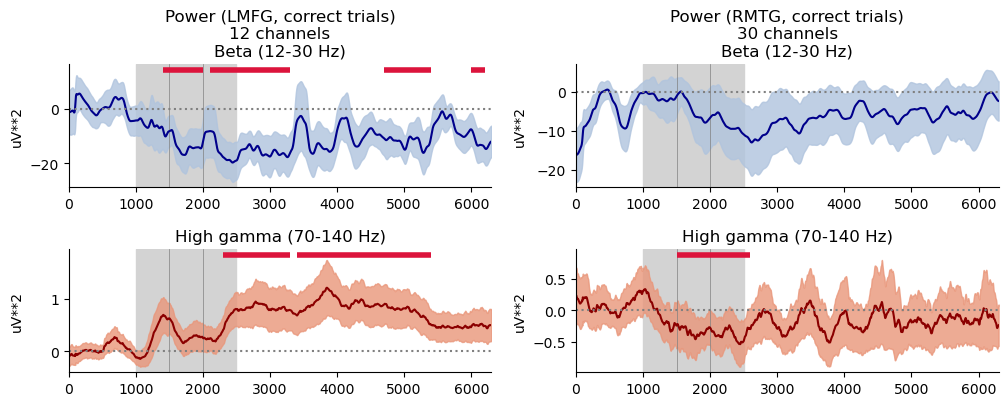

In [11]:
fig, ax = plt.subplots(2, 2, figsize = (12, 4))

for col_id, region in enumerate(["LMFG", "RMTG"]):
    for row_id, freq_band in enumerate(["beta", "high_gamma"]):
        ca = ax[row_id, col_id]

        ca.axvspan(1000, 2500, color = 'lightgray')
        ca.axvline(1500, color = 'gray', linewidth = 0.5)
        ca.axvline(2000, color = 'gray', linewidth = 0.5)

        power = processed_data[
            (processed_data["region"] == region) &
            (processed_data["freq_band"] == freq_band) &
            (processed_data["n_correct"] == 3) &
            (processed_data["modulated"] == 1)
        ]

        # Compute per-channel power
        power = power[utils.POWER_COLS + ["subject", "channel"]]
        power = power.groupby(["subject", "channel"]).agg(lambda x: np.nanmean(x, axis = 0)).reset_index()[utils.POWER_COLS].to_numpy()
        n_channels = len(power)

        # Baseline-correct
        power = power - np.nanmean(power[:, utils.BASELINE[0] : utils.BASELINE[1]], axis = 1, keepdims = True)
        power = power[:, :utils.CUTOFF]

        # Compute stats
        avg_power = np.nanmean(power, axis = 0)
        sem_power = np.nanstd(power, axis = 0) / np.sqrt(n_channels)

        ca.plot(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_power, 200),
            color = utils.PLOTTING[freq_band]["color"]
        )
        ca.fill_between(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_power - sem_power, 200),
            uniform_filter1d(avg_power + sem_power, 200),
            color = utils.PLOTTING[freq_band]["fillcolor"],
            alpha = 0.8
        )

        # Cluster-test
        step = 100
        win_range = np.arange(0, len(utils.POWER_COLS), step)
        clusters = cluster_test_period(
            sample = power,
            period = utils.BASELINE,
            win_range = win_range,
            win_size = 200
        )

        if len(clusters) > 0:
            yval = ca.get_ylim()[1]
            for tstat_id, period in enumerate(win_range):
                if (period < 100) or (period >= utils.CUTOFF - 100): continue
                if clusters[tstat_id] == 0: continue
                ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)

        if row_id == 0:
            title = f"Power ({region}, correct trials)\n{n_channels} channels\n{utils.PLOTTING[freq_band]['title']}"
        else:
            title = utils.PLOTTING[freq_band]['title']
        ca.set_title(title)

        ca.set_ylabel("uV**2")
        ca.axhline(0, ls = "dotted", color = "gray")
        ca.set_xlim(0, utils.CUTOFF)
        ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(hspace = 0.5)

## High gamma (Fig. 2b) and beta (Fig. 3b) bursting in single trials

In [12]:
subject = "sub-P1"

channels = {
    0: {
        "channel": 7,
        "region": "LMFG",
        "freq_band": "high_gamma",
        "trial": 3,
        "window": (3500, 3900)
    },
    1 : {
        "channel": 66,
        "region": "RMTG",
        "freq_band": "beta",
        "trial": 78,
        "window": (300, 1000)
    }
}

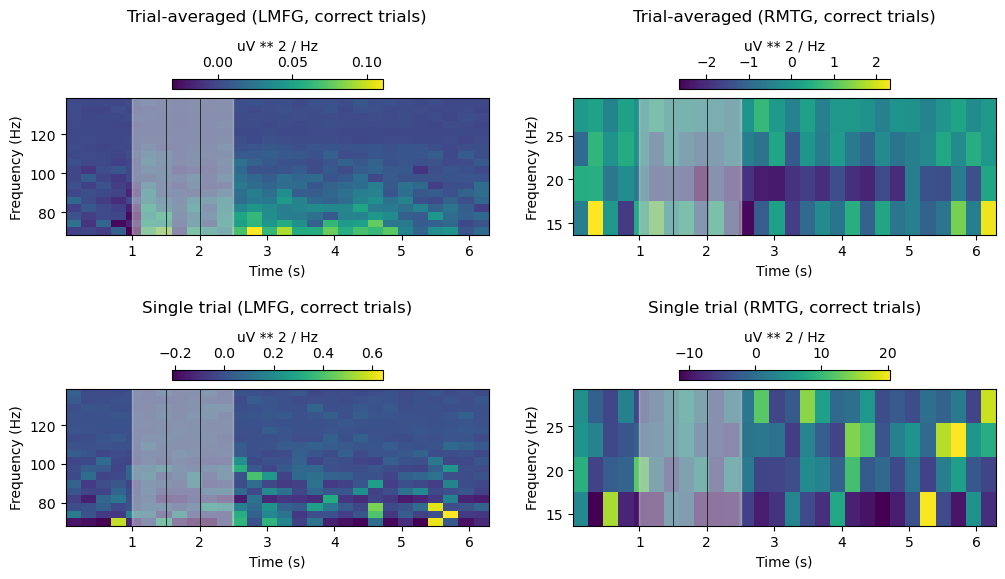

In [13]:
fig, ax = plt.subplots(2, 2, figsize = (12, 6))

for col_id in range(2):

    channel_to_show = data[
        (data["subject"] == subject) &
        (data["channel"] == channels[col_id]["channel"]) & 
        (data["n_correct"] == 3)
    ][utils.LFP_COLS].to_numpy()

    # Compute the spectrogram
    f, t, Sxx = signal.spectrogram(channel_to_show, fs = 1000, nperseg = 256, axis = -1)
    Sxx = Sxx - np.nanmean(Sxx[:, :, t < 1], axis = 2, keepdims = True)

    f_min = utils.FREQ_BANDS[channels[col_id]["freq_band"]][0]
    f_max = utils.FREQ_BANDS[channels[col_id]["freq_band"]][1]

    for row_id in range(2):
        ca = ax[row_id, col_id]

        if row_id == 0:
            Sxx_to_plot = np.nanmean(Sxx, axis = 0)
            title = f"Trial-averaged ({channels[col_id]['region']}, correct trials)"
        else:
            Sxx_to_plot = Sxx[channels[col_id]["trial"]]
            title = f"Single trial ({channels[col_id]['region']}, correct trials)"

        im = ca.pcolormesh(
            t, 
            f[(f >= f_min) & (f <= f_max)], 
            Sxx_to_plot[(f >= f_min) & (f < f_max)], 
            cmap = 'viridis'
        )
        ca.axvspan(1.0, 2.5, color = 'lightgray', alpha = 0.5)
        ca.axvline(1.5, color = 'black', linewidth = 0.5)
        ca.axvline(2.0, color = 'black', linewidth = 0.5)

        ca.set_xlabel("Time (s)")
        ca.set_ylabel("Frequency (Hz)")

        cbar = fig.colorbar(im, location = "top", shrink = 0.5, ax = ca, label = "uV ** 2 / Hz")
        ca.set_title(title, y = 1.5)

plt.subplots_adjust(hspace = 0.7)

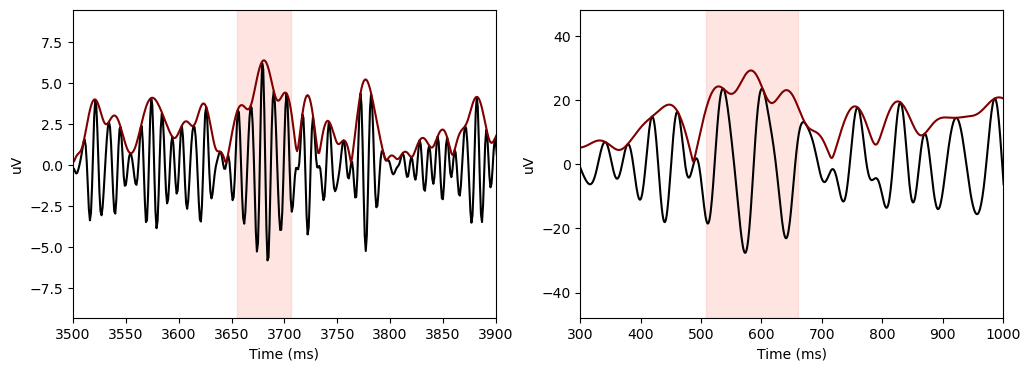

In [14]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for col_id in range(2):
    ca = ax[col_id]

    trial_to_show = data[
        (data["subject"] == subject) &
        (data["channel"] == channels[col_id]["channel"]) & 
        (data["n_correct"] == 3)
    ][utils.LFP_COLS].to_numpy()[channels[col_id]["trial"]]

    # Show filtered LFP and hilbert envelope
    sos = signal.butter(6, utils.FREQ_BANDS[channels[col_id]["freq_band"]] * 2 / 1000, "bandpass", output = 'sos')
    filtered_trial = signal.sosfiltfilt(sos, trial_to_show)
    hilb_env = np.abs(signal.hilbert(filtered_trial))

    # Show bursts
    trial_bursts = processed_data[
            (processed_data["subject"] == subject) &
            (processed_data["freq_band"] == channels[col_id]["freq_band"]) &
            (processed_data["channel"] == channels[col_id]["channel"]) &
            (processed_data["n_correct"] == 3)
    ][utils.BURST_COLS].to_numpy()[channels[col_id]["trial"]].flatten()
    burst_starts_ends = extract_burst_bounds(trial_bursts)

    for burst_idx in range(len(burst_starts_ends)):
        ca.axvspan(burst_starts_ends[burst_idx, 0], burst_starts_ends[burst_idx, 1], color = 'salmon', alpha = 0.2)

    # Note: power threshold can be retrieved by modifying burst_toolbox.detect_bursts()
    # Omitting here for clarity 

    ca.plot(filtered_trial, c = "black")
    ca.plot(hilb_env, c = "maroon")

    ca.set_xlim(*channels[col_id]["window"])
    ca.set_xlabel("Time (ms)")
    ca.set_ylabel("uV")

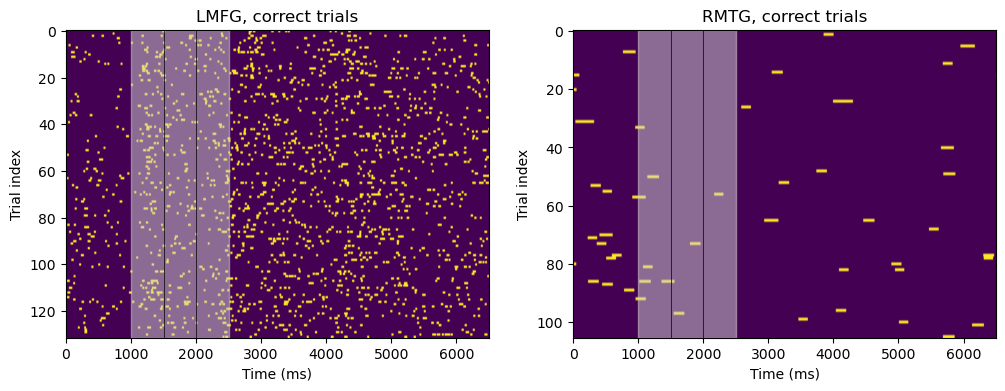

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for col_id in range(2):

    ca = ax[col_id]

    channel_to_show = processed_data[
        (processed_data["subject"] == subject) &
        (processed_data["channel"] == channels[col_id]["channel"]) & 
        (processed_data["freq_band"] == channels[col_id]["freq_band"]) &
        (processed_data["n_correct"] == 3)
    ][utils.BURST_COLS].to_numpy()

    ca.imshow(channel_to_show, aspect = "auto")
    ca.set_title(f"{channels[col_id]['region']}, correct trials")
    ca.set_xlabel("Time (ms)")
    ca.set_ylabel("Trial index")

    ca.axvspan(1000, 2500, color = 'lightgray', alpha = 0.5)
    ca.axvline(1500, color = 'black', linewidth = 0.5)
    ca.axvline(2000, color = 'black', linewidth = 0.5)

## Beta and high gamma burst rate in LMFG (Fig. 2c) and RMTG (Fig. 3c)

**Note:** takes ~1 min. to run due to cluster testing.

/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)
/Users/vladimiromelyusik/burst_toolbox/src/burst_toolbox/stats.py:163: RuntimeWarning: Mean of empty slice
  sample_window = np.nanmean(sample[:, win_id : win_id + win_size], axis = 1)


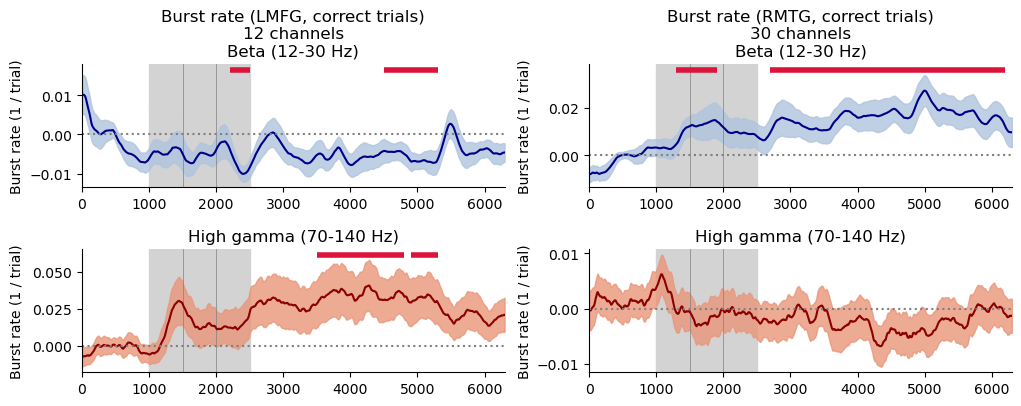

In [16]:
fig, ax = plt.subplots(2, 2, figsize = (12, 4))

for col_id, region in enumerate(["LMFG", "RMTG"]):
    for row_id, freq_band in enumerate(["beta", "high_gamma"]):
        ca = ax[row_id, col_id]

        ca.axvspan(1000, 2500, color = 'lightgray')
        ca.axvline(1500, color = 'gray', linewidth = 0.5)
        ca.axvline(2000, color = 'gray', linewidth = 0.5)

        burst_rate = processed_data[
            (processed_data["region"] == region) &
            (processed_data["freq_band"] == freq_band) &
            (processed_data["n_correct"] == 3) &
            (processed_data["modulated"] == 1)
        ]

        # Compute per-channel burst rate
        burst_rate = burst_rate[utils.BURST_COLS + ["subject", "channel"]]
        burst_rate = burst_rate.groupby(["subject", "channel"]).agg(lambda x: np.nanmean(x, axis = 0)).reset_index()[utils.BURST_COLS].to_numpy()
        n_channels = len(burst_rate)

        # Baseline-correct
        burst_rate = burst_rate - np.nanmean(burst_rate[:, utils.BASELINE[0] : utils.BASELINE[1]], axis = 1, keepdims = True)
        burst_rate = burst_rate[:, :utils.CUTOFF]

        # Compute stats
        avg_burst_rate = np.nanmean(burst_rate, axis = 0)
        sem_burst_rate = np.nanstd(burst_rate, axis = 0) / np.sqrt(n_channels)

        ca.plot(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_burst_rate, 200),
            color = utils.PLOTTING[freq_band]["color"]
        )
        ca.fill_between(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_burst_rate - sem_burst_rate, 200),
            uniform_filter1d(avg_burst_rate + sem_burst_rate, 200),
            color = utils.PLOTTING[freq_band]["fillcolor"],
            alpha = 0.8
        )

        # Cluster-test
        step = 100
        win_range = np.arange(0, len(utils.BURST_COLS), step)
        clusters = cluster_test_period(
            sample = burst_rate,
            period = utils.BASELINE,
            win_range = win_range,
            win_size = 200,
            stat_q_threshold = 0.975 # Was 0.95 when working on the paper, now using a tighter threshold
        )

        if len(clusters) > 0:
            yval = ca.get_ylim()[1]
            for tstat_id, period in enumerate(win_range):
                if (period < 100) or (period >= utils.CUTOFF - 100): continue
                if clusters[tstat_id] == 0: continue
                ca.hlines(yval, period, period + step, color = 'crimson', linewidth = 4)

        if row_id == 0:
            title = f"Burst rate ({region}, correct trials)\n{n_channels} channels\n{utils.PLOTTING[freq_band]['title']}"
        else:
            title = utils.PLOTTING[freq_band]['title']
        ca.set_title(title)

        ca.set_ylabel("Burst rate (1 / trial)")
        ca.axhline(0, ls = "dotted", color = "gray")
        ca.set_xlim(0, utils.CUTOFF)
        ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(hspace = 0.5)

## Temporal anti-correlation between beta and high gamma burst rates in LMFG (Fig. 2d) and RMTG (Fig. 3d)

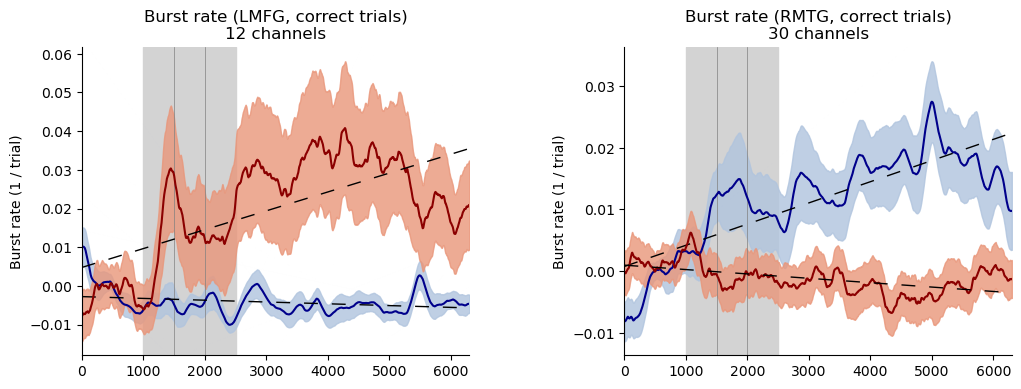

In [17]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for col_id, region in enumerate(["LMFG", "RMTG"]):
        
    ca = ax[col_id]
    ca.axvspan(1000, 2500, color = 'lightgray')
    ca.axvline(1500, color = 'gray', linewidth = 0.5)
    ca.axvline(2000, color = 'gray', linewidth = 0.5)

    for freq_band in ["beta", "high_gamma"]:

        burst_rate = processed_data[
            (processed_data["region"] == region) &
            (processed_data["freq_band"] == freq_band) &
            (processed_data["n_correct"] == 3) &
            (processed_data["modulated"] == 1)
        ]

        # Compute per-channel burst rate
        burst_rate = burst_rate[utils.BURST_COLS + ["subject", "channel"]]
        burst_rate = burst_rate.groupby(["subject", "channel"]).agg(lambda x: np.nanmean(x, axis = 0)).reset_index()[utils.BURST_COLS].to_numpy()
        n_channels = len(burst_rate)

        # Baseline-correct
        burst_rate = burst_rate - np.nanmean(burst_rate[:, utils.BASELINE[0] : utils.BASELINE[1]], axis = 1, keepdims = True)
        burst_rate = burst_rate[:, :utils.CUTOFF]

        # Compute stats
        avg_burst_rate = np.nanmean(burst_rate, axis = 0)
        sem_burst_rate = np.nanstd(burst_rate, axis = 0) / np.sqrt(n_channels)

        # Plot burst rates
        ca.plot(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_burst_rate, 200),
            color = utils.PLOTTING[freq_band]["color"]
        )
        ca.fill_between(
            np.arange(utils.CUTOFF),
            uniform_filter1d(avg_burst_rate - sem_burst_rate, 200),
            uniform_filter1d(avg_burst_rate + sem_burst_rate, 200),
            color = utils.PLOTTING[freq_band]["fillcolor"],
            alpha = 0.8
        )

        # Plot the OLS fit
        lr = LinearRegression()
        lr.fit(np.arange(utils.CUTOFF).reshape((-1, 1)), avg_burst_rate)
        ca.plot(
            np.arange(utils.CUTOFF), 
            lr.intercept_ + lr.coef_ * np.arange(utils.CUTOFF), 
            color = 'black', ls = '--', linewidth = 1, dashes = (10, 10))
        
        title = f"Burst rate ({region}, correct trials)\n{n_channels} channels"
        ca.set_title(title)

        ca.set_ylabel("Burst rate (1 / trial)")
        ca.set_xlim(0, utils.CUTOFF)
        ca.spines[["top", "right"]].set_visible(False)

fig.align_labels()
plt.subplots_adjust(wspace = 0.4)